In [6]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/scRNA_project")
DATASETS = PROJECT / "datasets"

%cd {PROJECT}

!pip install scanpy leidenalg igraph -q

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

adata = sc.read_h5ad(
    DATASETS / "pbmc3k_pca_umap.h5ad"
)

print(adata)
print("Shape:", adata.shape)
print("Has raw:", adata.raw is not None)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/scRNA_project
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 78.2 MB/s eta 0:00:00
AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: 'counts', None (.X)
Shape: (2638, 13714)
Has raw: True


In [7]:
sc.tl.leiden(
    adata,
    resolution=0.5,
    random_state=42,
    flavor="igraph",
    n_iterations=2,
    directed=False
)

print(
    adata.obs["leiden"]
    .value_counts()
    .sort_index()
)

leiden
0    681
1    304
2    466
3    344
4    212
5    155
6    429
7     35
8     12
Name: count, dtype: int64


In [8]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    use_raw=True
)

print("Marker analysis completed.")

Marker analysis completed.


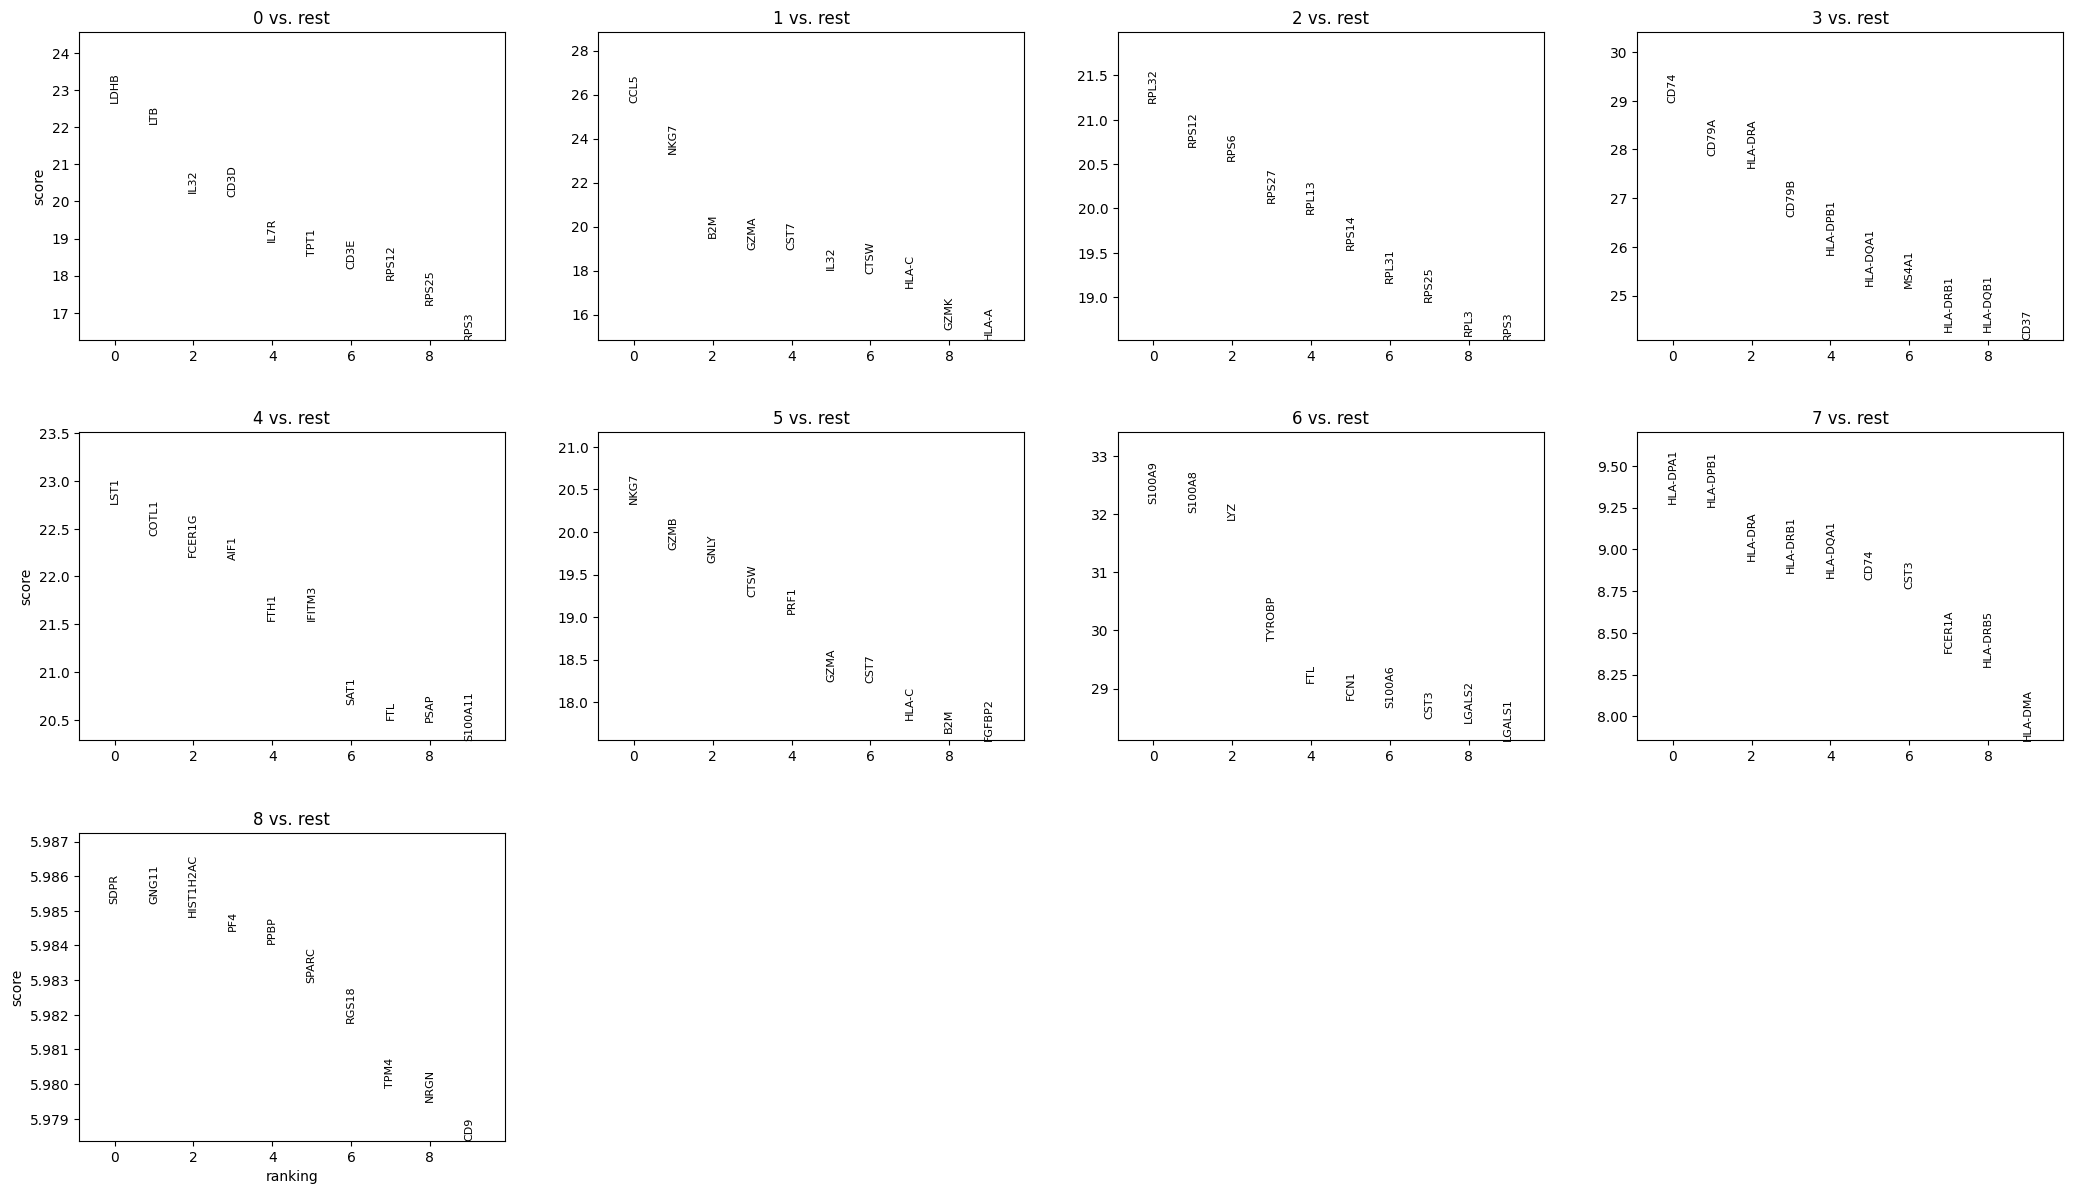

In [9]:
sc.pl.rank_genes_groups(
    adata,
    n_genes=10,
    sharey=False
)

In [10]:
clustered_file = DATASETS / "pbmc3k_clustered.h5ad"

adata.write(clustered_file)

print("Saved:", clustered_file)

Saved: /content/drive/MyDrive/scRNA_project/datasets/pbmc3k_clustered.h5ad


In [11]:
print("Files in datasets:")

for p in sorted(DATASETS.iterdir()):
    print(p.name)

Files in datasets:
.gitkeep
pbmc3k_clustered.h5ad
pbmc3k_filtered.h5ad
pbmc3k_normalized_hvg.h5ad
pbmc3k_pca_umap.h5ad


In [12]:
cluster2celltype = {
    "0": "T cell",
    "1": "Cytotoxic T / NK-like",
    "2": "T cell",
    "3": "B cell",
    "4": "Classical Monocyte",
    "5": "NK cell",
    "6": "Classical Monocyte",
    "7": "Dendritic cell",
    "8": "Platelet / Megakaryocyte"
}

print(cluster2celltype)

{'0': 'T cell', '1': 'Cytotoxic T / NK-like', '2': 'T cell', '3': 'B cell', '4': 'Classical Monocyte', '5': 'NK cell', '6': 'Classical Monocyte', '7': 'Dendritic cell', '8': 'Platelet / Megakaryocyte'}


In [13]:
adata.obs["cell_type"] = (
    adata.obs["leiden"]
    .map(cluster2celltype)
)

In [14]:
print("Unmapped cells:", adata.obs["cell_type"].isna().sum())

Unmapped cells: 0


In [15]:
print(adata.obs["cell_type"].value_counts())

cell_type
T cell                      1147
Classical Monocyte           641
B cell                       344
Cytotoxic T / NK-like        304
NK cell                      155
Dendritic cell                35
Platelet / Megakaryocyte      12
Name: count, dtype: int64


In [16]:
adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")

print(adata.obs["cell_type"].cat.categories)

Index(['B cell', 'Classical Monocyte', 'Cytotoxic T / NK-like',
       'Dendritic cell', 'NK cell', 'Platelet / Megakaryocyte', 'T cell'],
      dtype='str')


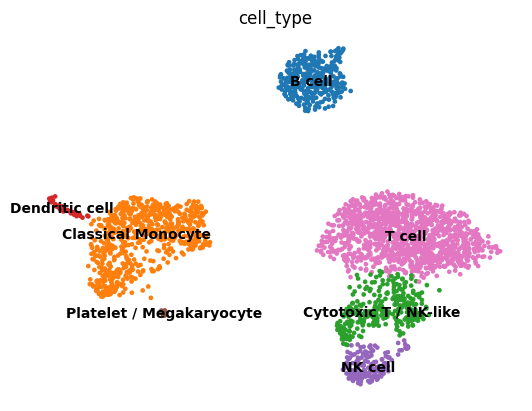

In [17]:
sc.pl.umap(
    adata,
    color="cell_type",
    legend_loc="on data",
    frameon=False
)

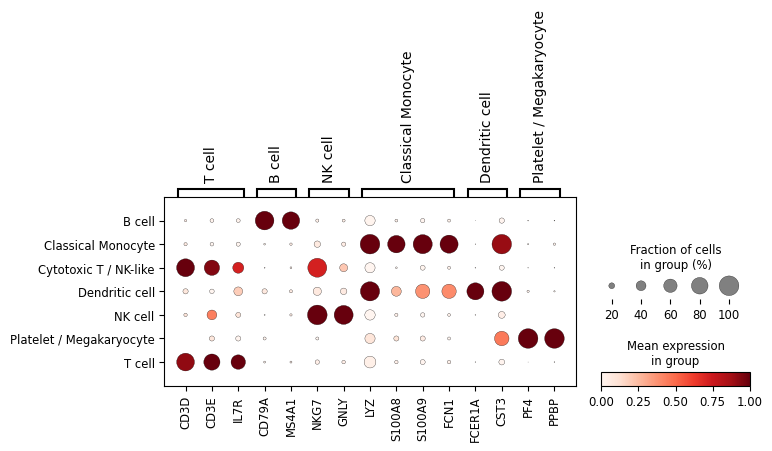

In [18]:
final_markers = {
    "T cell": ["CD3D", "CD3E", "IL7R"],
    "B cell": ["CD79A", "MS4A1"],
    "NK cell": ["NKG7", "GNLY"],
    "Classical Monocyte": ["LYZ", "S100A8", "S100A9", "FCN1"],
    "Dendritic cell": ["FCER1A", "CST3"],
    "Platelet / Megakaryocyte": ["PF4", "PPBP"]
}

sc.pl.dotplot(
    adata,
    final_markers,
    groupby="cell_type",
    standard_scale="var"
)

In [19]:
final_file = DATASETS / "pbmc3k_final.h5ad"

adata.write(str(final_file))

print("Saved:", final_file)

Saved: /content/drive/MyDrive/scRNA_project/datasets/pbmc3k_final.h5ad


In [20]:
print("Final dataset:")
print(final_file)

print("\nExists:", final_file.exists())

Final dataset:
/content/drive/MyDrive/scRNA_project/datasets/pbmc3k_final.h5ad

Exists: True


In [21]:
print(adata)
print("\nObs columns:")
print(adata.obs.columns.tolist())

print("\nCell types:")
print(adata.obs["cell_type"].value_counts())

AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'cell_type'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap', 'leiden', 'rank_genes_groups', 'cell_type_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: 'counts', None (.X)

Obs columns:
['n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'cell_type']

Cell types:
cell_type
T cell                      1147
Classical Monocyte           641
B cell                       344
Cytotoxic T / NK-like        304
NK cell                      155
Dendritic cell                35
Platelet / Megakaryocyte      12
Name: count, dtype: int64


In [22]:
print("Files in datasets:")

for p in sorted(DATASETS.iterdir()):
    print(p.name)

Files in datasets:
.gitkeep
pbmc3k_clustered.h5ad
pbmc3k_filtered.h5ad
pbmc3k_final.h5ad
pbmc3k_normalized_hvg.h5ad
pbmc3k_pca_umap.h5ad


In [24]:
from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/scRNA_project")
%cd {PROJECT}

readme_content = (
    "# scRNA-seq Analysis Project\n\n"
    "A structured computational biology project for learning and applying "
    "Python, Scanpy, and single-cell RNA-seq analysis.\n\n"
    "## Project Overview\n\n"
    "This project demonstrates a reproducible single-cell RNA-seq analysis "
    "workflow using the PBMC3k dataset.\n\n"
    "The first phase focuses on building practical skills in Python, "
    "AnnData, Scanpy, quality control, dimensionality reduction, "
    "clustering, marker-gene analysis, and cell-type annotation.\n\n"
    "The project is designed as a skill-demonstration and portfolio project, "
    "rather than a novel biological discovery study.\n\n"
    "## Phase 1 — PBMC3k\n\n"
    "### Completed Workflow\n\n"
    "Raw PBMC3k\n"
    "→ Quality Control\n"
    "→ Cell Filtering\n"
    "→ Normalization\n"
    "→ Log Transformation\n"
    "→ Highly Variable Gene Selection\n"
    "→ Scaling\n"
    "→ PCA\n"
    "→ Neighbors\n"
    "→ UMAP\n"
    "→ Leiden Clustering\n"
    "→ Marker Gene Analysis\n"
    "→ Cell-type Annotation\n\n"
    "### Completed Lessons\n\n"
    "- Lesson 01 — Python environment and variables\n"
    "- Lesson 02 — Lists and dictionaries\n"
    "- Lesson 03 — Loops and conditions\n"
    "- Lesson 04 — Functions\n"
    "- Lesson 05 — Objects and AnnData structure\n"
    "- Lesson 06 — NumPy basics\n"
    "- Lesson 07 — Pandas basics\n"
    "- Lesson 08 — Matplotlib basics\n"
    "- Lesson 09 — Quality control with Scanpy\n"
    "- Lesson 10 — File paths, saving and loading AnnData\n"
    "- Lesson 11 — Git and GitHub project setup\n"
    "- Lesson 12 — Normalization, HVG selection, PCA and UMAP\n"
    "- Lesson 13 — Leiden clustering and marker-gene analysis\n"
    "- Lesson 14 — Cell-type annotation and PBMC3k pipeline finalization\n\n"
    "## Cell-type Annotation\n\n"
    "Cell identities were assigned based on Leiden clusters, ranked marker "
    "genes, and canonical marker-gene expression.\n\n"
    "The final annotation includes:\n\n"
    "- T cell\n"
    "- Cytotoxic T / NK-like\n"
    "- B cell\n"
    "- NK cell\n"
    "- Classical Monocyte\n"
    "- Dendritic cell\n"
    "- Platelet / Megakaryocyte\n\n"
    "## Repository Structure\n\n"
    "scRNA_project/\n"
    "├── datasets/\n"
    "├── notebooks/\n"
    "├── .gitignore\n"
    "├── requirements.txt\n"
    "└── README.md\n\n"
    "Large .h5ad files are kept locally in the datasets directory and "
    "excluded from Git tracking.\n\n"
    "## Next Phase\n\n"
    "The next stage of the project will apply the learned single-cell "
    "RNA-seq workflow to a real colorectal cancer dataset (GSE132465).\n\n"
    "A separate R-based analysis track will also be developed for "
    "TCGA-COAD transcriptomics and statistical analysis.\n"
)

readme_path = PROJECT / "README.md"
readme_path.write_text(readme_content, encoding="utf-8")

print("README updated:", readme_path)

/content/drive/MyDrive/scRNA_project
README updated: /content/drive/MyDrive/scRNA_project/README.md


In [25]:
print((PROJECT / "README.md").read_text(encoding="utf-8")[:2000])

# scRNA-seq Analysis Project

A structured computational biology project for learning and applying Python, Scanpy, and single-cell RNA-seq analysis.

## Project Overview

This project demonstrates a reproducible single-cell RNA-seq analysis workflow using the PBMC3k dataset.

The first phase focuses on building practical skills in Python, AnnData, Scanpy, quality control, dimensionality reduction, clustering, marker-gene analysis, and cell-type annotation.

The project is designed as a skill-demonstration and portfolio project, rather than a novel biological discovery study.

## Phase 1 — PBMC3k

### Completed Workflow

Raw PBMC3k
→ Quality Control
→ Cell Filtering
→ Normalization
→ Log Transformation
→ Highly Variable Gene Selection
→ Scaling
→ PCA
→ Neighbors
→ UMAP
→ Leiden Clustering
→ Marker Gene Analysis
→ Cell-type Annotation

### Completed Lessons

- Lesson 01 — Python environment and variables
- Lesson 02 — Lists and dictionaries
- Lesson 03 — Loops and conditions
- Lesson 04 

In [26]:
%cd "/content/drive/MyDrive/scRNA_project"

!git status

/content/drive/MyDrive/scRNA_project
Refresh index: 100% (18/18), done.
On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   README.md
	modified:   notebooks/Lesson13_Clustering_and_Marker_Genes.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/Lesson14_Cell_Annotation_and_Finalization.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
